In [1]:
import pandas as pd

df = pd.read_csv('netflix_customer_churn.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(5000, 14)
['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [2]:
# Missing values check
print("Missing Values:")
print(df.isnull().sum())

# Churn rate
print(f"\nTotal Customers: {len(df)}")
print(f"Churned: {df['churned'].sum()}")
print(f"Churn Rate: {df['churned'].mean()*100:.1f}%")

# Revenue at risk
churned_revenue = df[df['churned']==1]['monthly_fee'].sum()
print(f"\nRevenue Lost: ${churned_revenue:,.2f}/month")

Missing Values:
customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

Total Customers: 5000
Churned: 2515
Churn Rate: 50.3%

Revenue Lost: $33,009.85/month


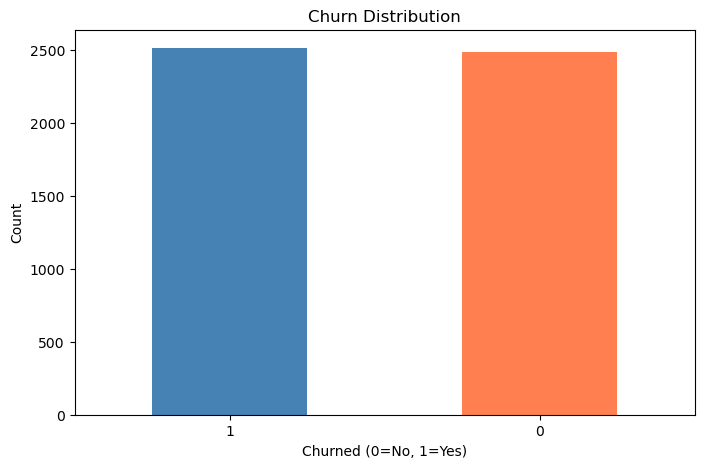

Insight: 50.3% users churn kar rahe hain — industry average 6-8% hai. Yeh alarming hai!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1 — Churn Distribution
plt.figure(figsize=(8,5))
df['churned'].value_counts().plot(kind='bar', color=['steelblue','coral'])
plt.title('Churn Distribution')
plt.xlabel('Churned (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
print("Insight: 50.3% users churn kar rahe hain — industry average 6-8% hai. Yeh alarming hai!")

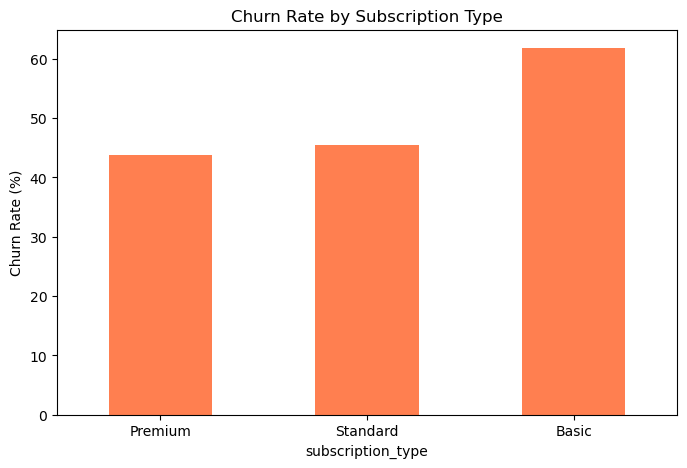

Insight: Basic subscribers sabse zyada churn karte hain


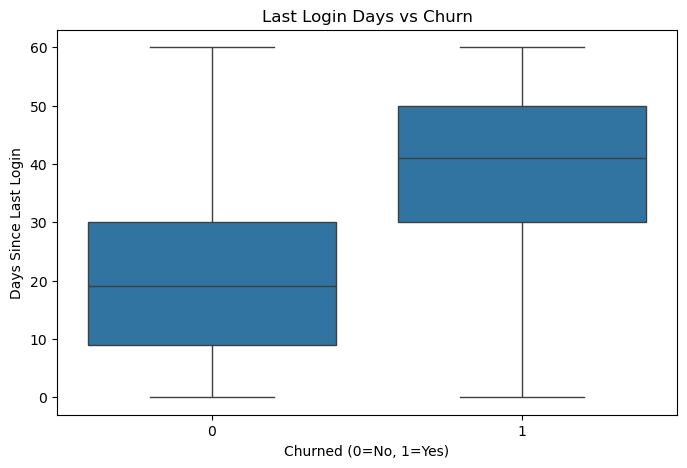

Insight: Zyada din se login nahi = zyada churn probability


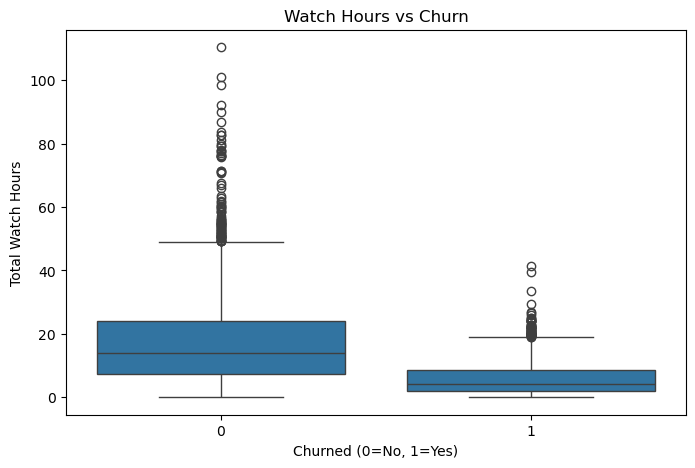

Insight: Kam watch hours wale users zyada churn karte hain


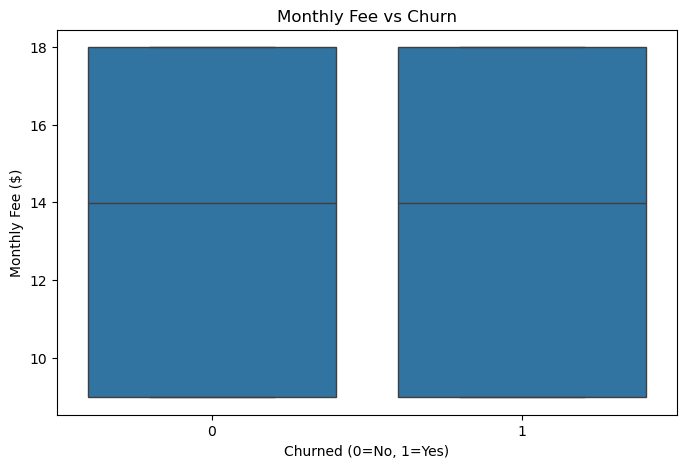

Insight: Higher fee = higher churn tendency


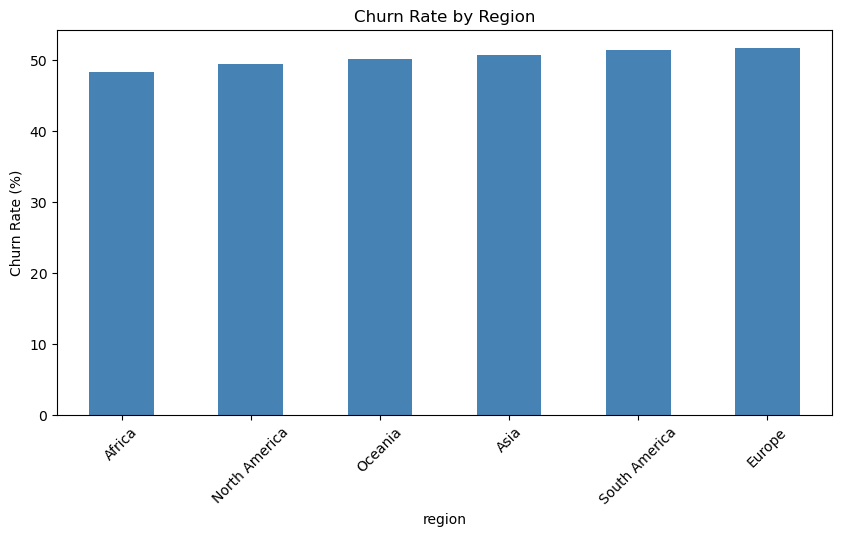

Insight: Europe region mein sabse zyada churn


In [5]:
# Chart 2 — Subscription Type vs Churn
plt.figure(figsize=(8,5))
sub_churn = df.groupby('subscription_type')['churned'].mean() * 100
sub_churn.sort_values().plot(kind='bar', color='coral')
plt.title('Churn Rate by Subscription Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()
print(f"Insight: {sub_churn.idxmax()} subscribers sabse zyada churn karte hain")

# Chart 3 — Last Login Days vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='churned', y='last_login_days', data=df)
plt.title('Last Login Days vs Churn')
plt.xlabel('Churned (0=No, 1=Yes)')
plt.ylabel('Days Since Last Login')
plt.show()
print("Insight: Zyada din se login nahi = zyada churn probability")

# Chart 4 — Watch Hours vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='churned', y='watch_hours', data=df)
plt.title('Watch Hours vs Churn')
plt.xlabel('Churned (0=No, 1=Yes)')
plt.ylabel('Total Watch Hours')
plt.show()
print("Insight: Kam watch hours wale users zyada churn karte hain")

# Chart 5 — Monthly Fee vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='churned', y='monthly_fee', data=df)
plt.title('Monthly Fee vs Churn')
plt.xlabel('Churned (0=No, 1=Yes)')
plt.ylabel('Monthly Fee ($)')
plt.show()
print("Insight: Higher fee = higher churn tendency")

# Chart 6 — Region vs Churn
plt.figure(figsize=(10,5))
region_churn = df.groupby('region')['churned'].mean() * 100
region_churn.sort_values().plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Region')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()
print(f"Insight: {region_churn.idxmax()} region mein sabse zyada churn")

In [6]:
# Revenue Impact by Segment
print("=" * 50)
print("REVENUE IMPACT ANALYSIS")
print("=" * 50)

# By subscription type
rev_impact = df[df['churned']==1].groupby('subscription_type')['monthly_fee'].agg(['sum','count'])
rev_impact.columns = ['Revenue_Lost', 'Users_Churned']
rev_impact['Avg_Fee'] = rev_impact['Revenue_Lost'] / rev_impact['Users_Churned']
print("\nRevenue Lost by Subscription Type:")
print(rev_impact)

# By region
print("\nRevenue Lost by Region:")
region_rev = df[df['churned']==1].groupby('region')['monthly_fee'].sum().sort_values(ascending=False)
print(region_rev)

# Total impact
total_monthly = df[df['churned']==1]['monthly_fee'].sum()
total_yearly = total_monthly * 12
print(f"\nTotal Monthly Revenue Lost: ${total_monthly:,.2f}")
print(f"Total Yearly Revenue Lost: ${total_yearly:,.2f}")
print(f"In INR (approx): ₹{total_yearly*83:,.0f}")

REVENUE IMPACT ANALYSIS

Revenue Lost by Subscription Type:
                   Revenue_Lost  Users_Churned  Avg_Fee
subscription_type                                      
Basic                   9232.73           1027     8.99
Premium                13312.60            740    17.99
Standard               10464.52            748    13.99

Revenue Lost by Region:
region
Europe           5885.52
South America    5873.51
Asia             5567.74
North America    5523.79
Oceania          5127.17
Africa           5032.12
Name: monthly_fee, dtype: float64

Total Monthly Revenue Lost: $33,009.85
Total Yearly Revenue Lost: $396,118.20
In INR (approx): ₹32,877,811


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

df_ml = df.copy()
cat_cols = ['gender','subscription_type','region','device','payment_method','favorite_genre']

encoders = {}  # har column ka encoder store krne ke liye
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    encoders[col] = le  # future use ke liye save 

# Features aur target
X = df_ml.drop(['customer_id','churned'], axis=1)
y = df_ml['churned']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42)
}

print("Model Comparison:")
print("-" * 50)
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"{name}:")
    print(classification_report(y_test, pred))
    print(f"AUC-ROC: {auc:.3f}")
    print("-" * 50)

Model Comparison:
--------------------------------------------------
Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       497
           1       0.87      0.90      0.89       503

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000

AUC-ROC: 0.960
--------------------------------------------------
Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       497
           1       0.98      0.96      0.97       503

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000

AUC-ROC: 0.996
--------------------------------------------------
XGBoost:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99  

In [8]:
import subprocess
subprocess.run(['pip', 'install', 'shap'], capture_output=True)
print("SHAP installed!")

SHAP installed!


In [9]:
import shap
print("SHAP imported!")

SHAP imported!


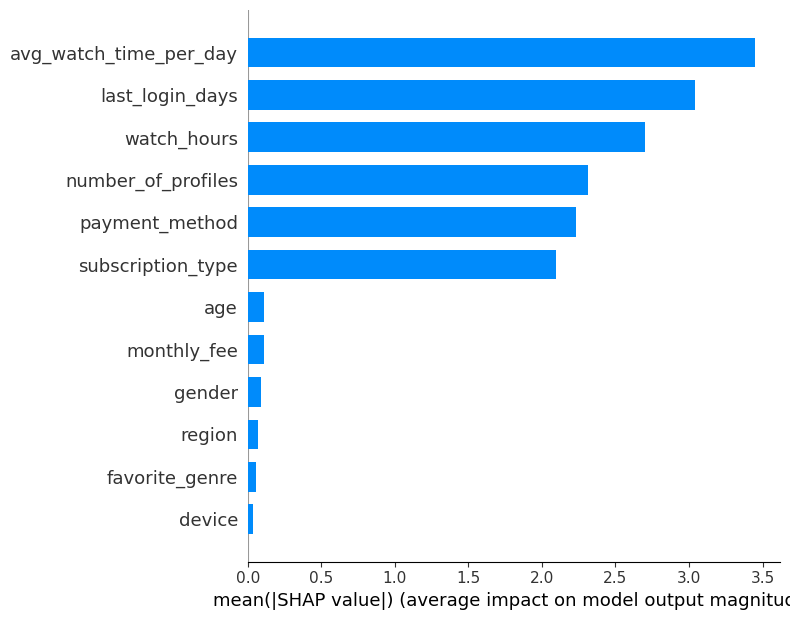

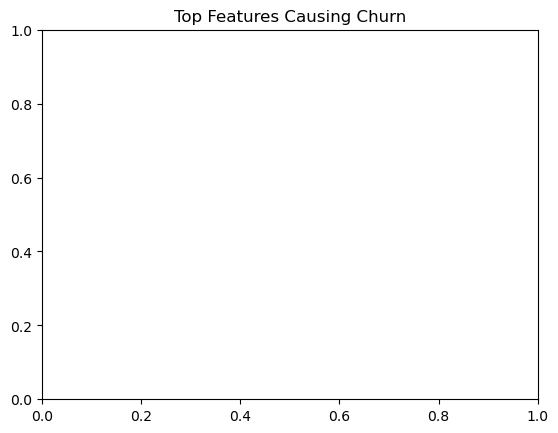

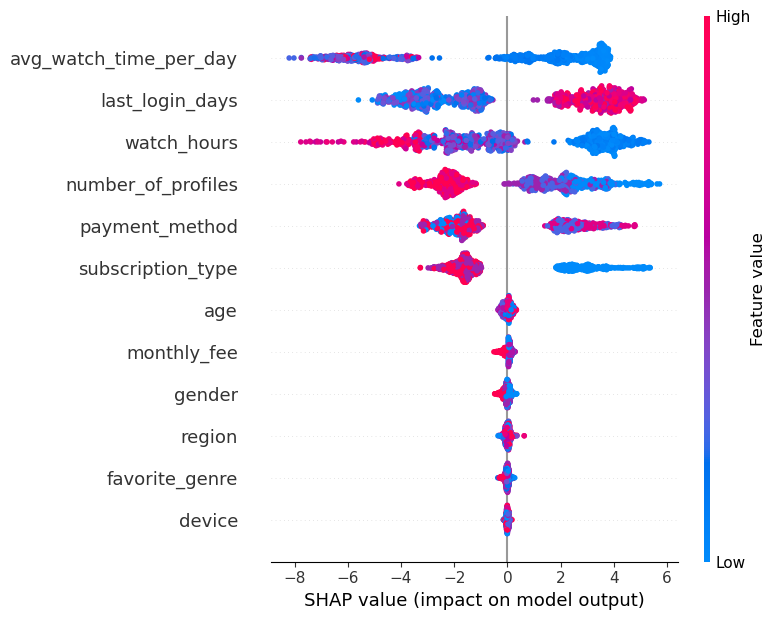

In [10]:
# SHAP Explainability
xgb_model = models['XGBoost']

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Feature importance
shap.summary_plot(shap_values, X_test, plot_type='bar')
plt.title('Top Features Causing Churn')
plt.show()

# Detailed plot
shap.summary_plot(shap_values, X_test)
plt.show()

In [12]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Risk Score Calculate 
rf_model = models['Random Forest']
df_ml['churn_probability'] = rf_model.predict_proba(X)[:,1]

# Risk Segments
df_ml['risk_segment'] = pd.cut(df_ml['churn_probability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Revenue at risk by segment
print("=" * 50)
print("RISK SEGMENTATION ANALYSIS")
print("=" * 50)

segment_analysis = df_ml.groupby('risk_segment').agg(
    Users=('customer_id', 'count'),
    Revenue_at_Risk=('monthly_fee', 'sum'),
    Avg_Watch_Hours=('watch_hours', 'mean')
).round(2)

print(segment_analysis)

# Retention ROI
high_risk = df_ml[df_ml['risk_segment']=='High Risk']
print(f"\nHigh Risk Users: {len(high_risk)}")
print(f"Revenue at Risk: ${high_risk['monthly_fee'].sum():,.2f}/month")
print(f"If 50% retained with 20% discount:")
retained_revenue = high_risk['monthly_fee'].sum() * 0.5 * 0.8
print(f"Revenue Saved: ${retained_revenue:,.2f}/month")

RISK SEGMENTATION ANALYSIS
              Users  Revenue_at_Risk  Avg_Watch_Hours
risk_segment                                         
Low Risk       1310         18458.90            14.76
Medium Risk      97          1360.03             9.40
High Risk      2457         32200.43             5.82

High Risk Users: 2457
Revenue at Risk: $32,200.43/month
If 50% retained with 20% discount:
Revenue Saved: $12,880.17/month
